![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_3/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  Recomendando Música

El objetivo de este caso-taller es construir un sistema de recomendación de Música utilizando los datos de [Last.fm](https://www.last.fm/) provistos  abiertamente por [grouplens](https://grouplens.org/about/what-is-grouplens/) para: **"avanzar la teoría y la práctica de la computación social mediante la construcción y la comprensión de sistemas *(de recomendación)* utilizados por personas reales".**

Los datos contienen información sobre artistas, usuarios, y las veces que estos escucharon sus canciones. Las bases se encuentran en los `Archivos de Laboratorio` en la carpeta `data`, allí también está disponible un archivo [README](data/readme.txt) que contiene más información sobre las bases.


## Instrucciones generales

1. Para desarrollar el *cuaderno*, primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1. Carga de datos

En la carpeta `data` se encuentran los archivos:

   - `artists.dat`  que contienen el identificador del artista (`id`), nombre (`name`), link a la página del artista en last.fm (`url`), y link a la imagen del usuario (`pictureURL`), vale aclarar que varios de estos links están rotos.
   - `user_artists.dat`  que contiene identificador del usuario (`userID`), nombre del artista que escuchó (`artistID`), y las veces que los escuchó (`weight`).

Cargue estos datos en su *cuaderno*:

   1. Para la base de artistas seleccione las columnas de identificador de artista (`id`) y nombre (`name`). Renombre estas columnas para poder hacer la unión con la base `user_artists.dat`.
   2. Para la base de usuarios y artistas, renombre las columnas de forma tal que se mantenga la consistencia para unir con la base anterior, y renombre la columna `weight` a `nro_reproducciones`.
   3. Una estas bases.
   

In [3]:
# Configuración del entorno

import pandas as pd
import numpy as np
import math
from sklearn.metrics.pairwise import cosine_similarity
!pip install apyori
from apyori import apriori
import matplotlib.pyplot as plt

#Clonamos el repositorio
!git clone https://github.com/camto-24/Taller-3-Aprendizaje-no-supervisado.git
!ls

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=49e5591005b5b913ef564b798d5f1d51779eccd3b334c67b00faefe7064d7d5c
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori
Cloning into 'Taller-3-Aprendizaje-no-supervisado'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 22 (delta 6), reused 16 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 2.15 MiB | 20.40 MiB/s, done.
Resolving deltas: 100% (6/6), done.
sample_data  Taller-3-Aprendizaje-no-supervisado


In [9]:
#Cargamos información de artistas
artistas = pd.read_csv('./data/artists.dat', sep='\t', encoding='latin-1')
artistas.head()
artistas.info()
artistas.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17632 entries, 0 to 17631
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          17632 non-null  int64 
 1   name        17632 non-null  object
 2   url         17632 non-null  object
 3   pictureURL  17188 non-null  object
dtypes: int64(1), object(3)
memory usage: 551.1+ KB


Index(['id', 'name', 'url', 'pictureURL'], dtype='object')

In [10]:
#Cargamos información música
musica = pd.read_csv('./data/user_artists.dat', sep='\t', encoding='latin-1')
musica.head()
musica.info()
musica.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92834 entries, 0 to 92833
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   userID    92834 non-null  int64
 1   artistID  92834 non-null  int64
 2   weight    92834 non-null  int64
dtypes: int64(3)
memory usage: 2.1 MB


Index(['userID', 'artistID', 'weight'], dtype='object')

In [11]:
#Estandarización de los nombres de las variables
artistas = artistas.rename(columns={'id': 'artistID','name': 'artist_name'})
artistas.head()

#Merge de las dos bases
base_total = pd.merge(musica,
    artistas,
    on='artistID',
    how='left'
)

base_total

,userID,artistID,weight,artist_name,url,pictureURL
0,2,51,13883,Duran Duran,http://www.last.fm/music/Duran+Duran,http://userserve-ak.last.fm/serve/252/155668.jpg
1,2,52,11690,Morcheeba,http://www.last.fm/music/Morcheeba,http://userserve-ak.last.fm/serve/252/46005111...
2,2,53,11351,Air,http://www.last.fm/music/Air,http://userserve-ak.last.fm/serve/252/251119.jpg
3,2,54,10300,Hooverphonic,http://www.last.fm/music/Hooverphonic,http://userserve-ak.last.fm/serve/252/40553471...
4,2,55,8983,Kylie Minogue,http://www.last.fm/music/Kylie+Minogue,http://userserve-ak.last.fm/serve/252/12740835...
...,...,...,...,...,...,...
92829,2100,18726,337,Nyktalgia,http://www.last.fm/music/Nyktalgia,http://userserve-ak.last.fm/serve/252/49060167...
92830,2100,18727,297,Atsakau niekadA,http://www.last.fm/music/Atsakau++niekadA,http://userserve-ak.last.fm/serve/252/29862435...
92831,2100,18728,281,Domantas Razauskas,http://www.last.fm/music/Domantas+Razauskas,http://userserve-ak.last.fm/serve/252/165556.jpg
92832,2100,18729,280,Atalyja,http://www.last.fm/music/Atalyja,http://userserve-ak.last.fm/serve/252/98093.jpg


En primer lugar se cargaron los archivos artists.dat y user_artists.dat, los cuales contienen la información de los artistas y las interacciones entre usuarios y artistas, respectivamente. Para ello, se utilizó la librería pandas, especificando que los archivos se encuentran separados por tabulaciones y utilizando una codificación adecuada para evitar problemas con caracteres especiales en los nombres de los artistas.

Seguido a esto, se realizó una revisión de la estructura de ambas bases de datos con el fin de identificar las variables relevantes para el análisis. Se observó que el identificador del artista tenía nombres distintos en cada tabla, por lo que fue necesario estandarizar los nombres de las variables. En particular, el identificador fue renombrado como `artistID` y el nombre del artista como artist_name, facilitando así la consistencia entre las bases y mejorando la claridad de la información.

Finalmente, se realizó la unión de las tablas mediante un merge usando `artistID` como llave común. Como resultado, se obtuvo una base que integra tanto las interacciones de los usuarios con los artistas como la información descriptiva de estos últimos.

### 2. Análisis preliminar.

En esta sección exploraremos la base. Para ello responda las siguientes preguntas.

#### 2.1 ¿Cuantos usuarios y artistas hay en la base?


In [12]:
#Fase exploratorioa: número de usuarios y artistas
n_usuarios = base_total['userID'].nunique()
n_artistas = base_total['artistID'].nunique()

print("Número de usuarios:", n_usuarios)
print("Número de artistas:", n_artistas)

Número de usuarios: 1892
Número de artistas: 17632


Con el fin de explorar la estructura general de la base, se calculó el número de usuarios y artistas únicos presentes en la base consolidada. Para esto, se contaron los valores distintos de las variables `userID` y `artistID`.





#### 2.2 ¿Cuál es la distribución de probabilidad del consumo por artista? (haga el calculo sin ponderar y ponderando por el numero de reproducciones) ¿Qué podemos inferir a partir de la comparación de ambas?

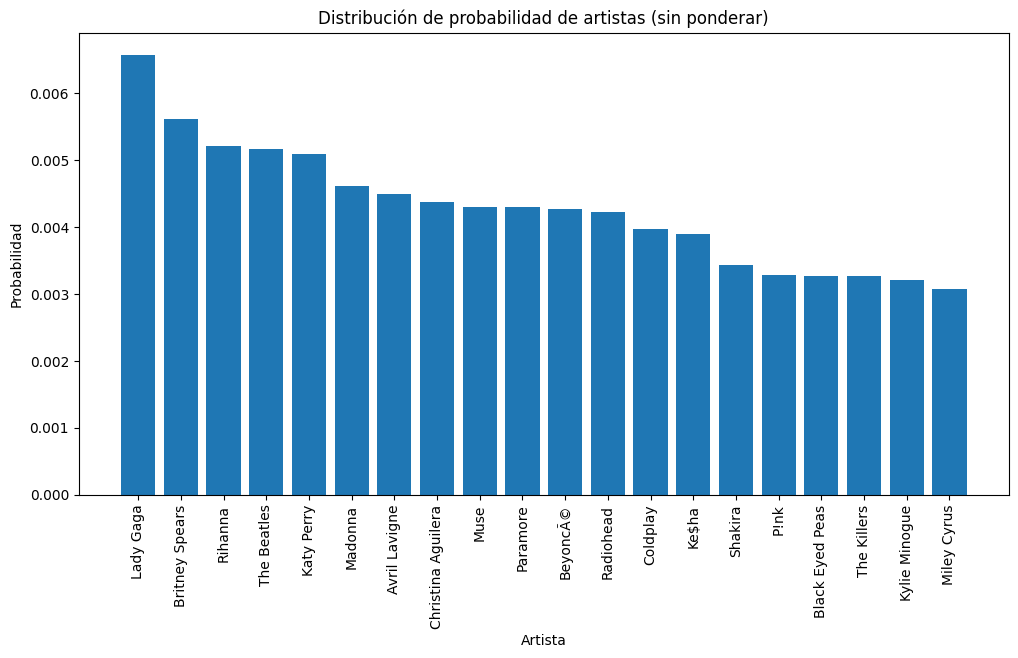

In [18]:
# Distribución de probabilidad del consumo por artista

#Sin ponderar
dist_sin = (
    base_total['artist_name']
    .value_counts(normalize=True)
    .reset_index()
)

dist_sin.columns = ['artist_name', 'probability']
dist_sin.head()

# Top 20 artistas más frecuentes
top_artistas_sin = dist_sin.head(20)

top_sin = dist_sin.sort_values(
    by='probability',
    ascending=False
).head(20)

# Gráfico
plt.figure(figsize=(12,6))

plt.bar(
    top_sin['artist_name'],
    top_sin['probability']
)

plt.xticks(rotation=90)

plt.title('Distribución de probabilidad de artistas (sin ponderar)')
plt.xlabel('Artista')
plt.ylabel('Probabilidad')

plt.show()


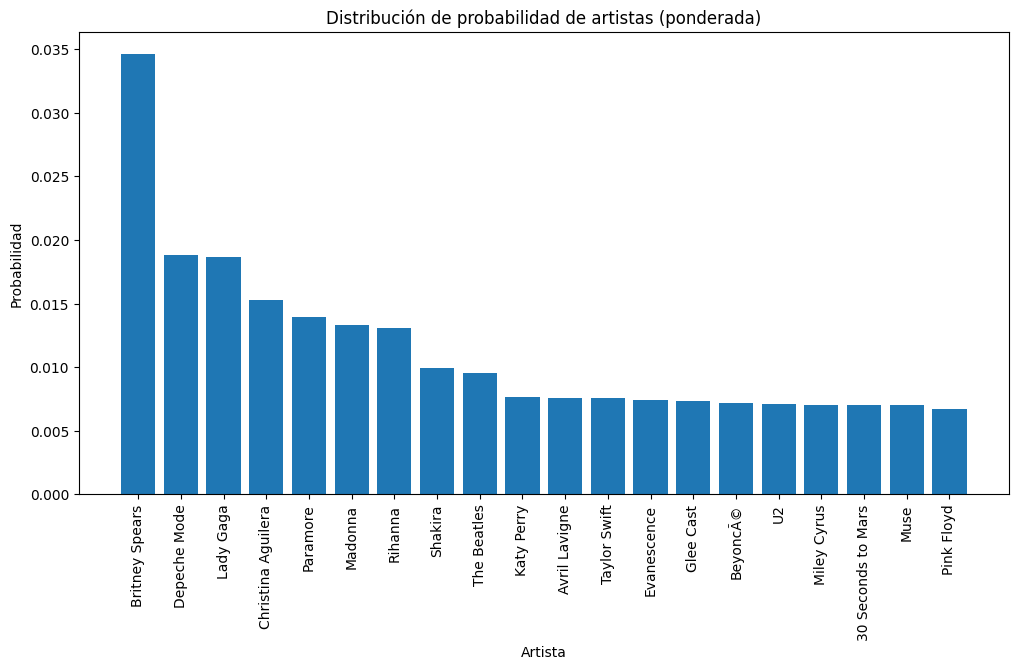

In [19]:
# Distribución de probabilidad del consumo por artista

#Ponderado
dist_con = (base_total.groupby('artist_name')['weight'].sum())

# Convertir en distribución de probabilidad
dist_proba_con = (dist_con / dist_con.sum()).reset_index()

dist_proba_con.columns = ['artist_name', 'probability']

dist_proba_con.head()

# Top 20 artistas consumo ponderado
top_ponderado = dist_proba_con.sort_values(by='probability',ascending=False).head(20)

# Gráfico
plt.figure(figsize=(12,6))

plt.bar(
    top_ponderado['artist_name'],
    top_ponderado['probability']
)

plt.xticks(rotation=90)

plt.title('Distribución de probabilidad de artistas (ponderada)')
plt.xlabel('Artista')
plt.ylabel('Probabilidad')

plt.show()


Al comparar las distribuciones de probabilidad sin ponderar y ponderada, se observan diferencias importantes en la forma en que ciertos artistas concentran la actividad de los usuarios. En la distribución sin ponderar, artistas como *Lady Gaga*, *Britney Spears* y *Rihanna* aparecen con alta frecuencia dentro de las interacciones registradas, lo que sugiere una amplia presencia entre los usuarios de la plataforma.

Sin embargo, al incorporar el número de reproducciones mediante la distribución ponderada, *Britney Spears* pasa a concentrar una proporción significativamente mayor del consumo total, mientras que aparecen artistas como Depeche Mode y The Beatles, que no destacaban tanto en la distribución anterior.

Esto indica que algunos artistas pueden tener una gran cantidad de usuarios oyentes, pero no necesariamente altos niveles de reproducción, mientras que otros presentan audiencias más intensivas en términos de consumo musical. En conjunto, ambas aproximaciones permiten distinguir entre popularidad por alcance e intensidad real de escucha, proporcionando un mayor entendimiento del consumo dentro de la plataforma.


#### 2.3 Para el usuario 8 (`userID==8`) ¿cuál es la distribución de reproducción de artistas basado en el número de reproducciones relativas?. Presente sus resultados usando tablas y/o gráficas. ¿Encuentra algún patrón en los artistas que escucha y las veces que reproduce? ¿Podemos decir algo de sus preferencias?


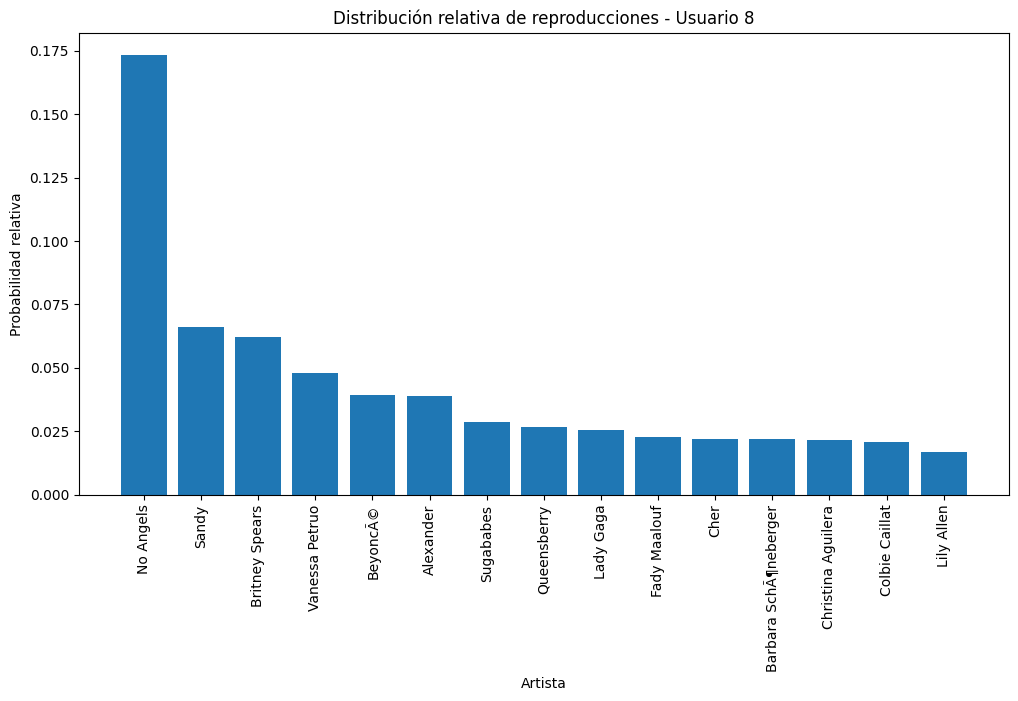

In [22]:
# Filtro para el usuario
user8 = base_total[base_total['userID'] == 8]

# Consumo total del usuario
total_user8 = user8['weight'].sum()

# Distribución relativa por artista
user8_dist = (
    user8.groupby('artist_name')['weight']
    .sum()
    .sort_values(ascending=False)
    / total_user8
).reset_index()

user8_dist.columns = ['artist_name', 'relative_probability']

user8_dist.head()

# Top 10 artistas del usuario
top_user8 = user8_dist.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_user8['artist_name'],
    top_user8['relative_probability']
)

plt.xticks(rotation=90)

plt.title('Distribución relativa de reproducciones - Usuario 8')
plt.xlabel('Artista')
plt.ylabel('Probabilidad relativa')

plt.show()

Con el fin de analizar las preferencias individuales del usuario 8, se calculó la distribución relativa de reproducciones por artista utilizando el número de reproducciones asociado a cada interacción.

Para ello, se estimó la proporción que representa cada artista sobre el total de reproducciones del usuario. La visualización obtenida permite identificar que las artistas *No Angels* son las más reproducidas, seguidas por *Sandy* y *Britney Spears*. Este análisis proporciona una aproximación inicial a las preferencias musicales del usuario y resulta fundamental para la construcción de sistemas de recomendación personalizados.

### 3. Generando Recomendaciones

En esta sección nos interesa generar recomendaciones ***nuevas y relevantes*** para el usuario 8 (`userID==8`). Para ello vamos a generar distintos sistemas de recomendación y comparar las recomendaciones generadas.

#### 3.1. Filtrado colaborativo sencillo: promedios simples.

Usando el promedio simple basado en el número de usuarios que escucha un artista (sin considerar el número de veces que estos usuarios reproducen al artista) genere una tabla y/o gráfica con 10 recomendaciones de artistas para este usuario. Explique con cuidado su procedimiento y justifique sus elecciones.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.2.  Filtrado colaborativo sencillo: promedios ponderados.

Usando el promedio ponderado basado en el número de usuarios que escucha un artista  y ponderando  por el número de veces que estos usuarios reproducen al artista (`nro_reproducciones`) genere una tabla y/o gráfica con 10 recomendaciones de artistas para este usuario. Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en el paso anterior.


In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.3.  Filtrado colaborativo sencillo: similitud de coseno.

Usando el promedio ponderado de reproducciones genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario. Para generar los pesos utilice la distancia de coseno. Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en el paso anterior.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.4.  Filtrado colaborativo usando SVD


Usando la descomposición en valores singulares (SVD) genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores.


In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

#### 3.5.  Filtrado colaborativo usando Análisis de Canasta de Compra

Usando  el algoritmo `Apriori` genere una tabla y/o gráfica  con 10 recomendaciones de artistas para este usuario.  Explique con cuidado su procedimiento y justifique sus elecciones. Compare las recomendaciones con el sistema implementado en los pasos anteriores. Esto puede tomar mucho tiempo, sea cuidadoso al elegir los hiper-parámetors del modelo, utilice los resultados de las estadísticas descriptivas para elegir sus hier-parámetros, y genere solo reglas con 2 elementos. (Puede también aprovechar los recursos de [Google Colab](https://colab.research.google.com/))


In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).

### 4. Recomendaciones generales

De acuerdo con los resultados encontrados, en su opinión ¿qué procedimiento generó las mejores recomendaciones para este usuario? ¿Cómo implementaría una evaluación objetiva de estas recomendaciones? Justifique su respuesta.

(Utilice este espacio para describir el procedimiento, análisis y conclusiones).